# はじめに
GitHub - junyanz/pytorch-CycleGAN-and-pix2pix: Image-to-Image Translation in PyTorch

https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix

↑こちらのREADMEを読みながら、自分用のメモも兼ねて作成したノートです

Google Colabratory上でCycleGANを動かしたい方の参考になれば幸いです

---


※ほぼ9割はREADMEに沿って進めているだけですが、visdomのエラーが初見殺しを仕掛けてくるのでそこだけ注意が必要です

---
『AIによる風景の†異世界変換† - Qiita』
https://qiita.com/onaka_yurusugi/items/93d2ca0ebc0cd6610dfe

↑この記事を書きました


# 1. まずは環境構築

Googleドライブと同期して作業内容を保存します

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 初回のみ必要

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/

!mkdir CycleGAN_Project
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project

# GitHubから本家CycleGANのクローンを生成
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix
!pip install -r requirements.txt

# ※Colabでのvisdomエラー対策
!git clone https://github.com/facebookresearch/visdom.git
%cd visdom
!pip install -e .
!pip install visdom dominate

%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix

In [ ]:
!pip install -U pip

Requirement already up-to-date: pip in /usr/local/lib/python3.7/dist-packages (19.3.1)


↓2回目以降はこれだけで大丈夫です

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix
!pip install -r requirements.txt
%cd visdom
!pip install -e .
!pip install visdom dominate
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix

/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix
     |████████████████████████████████| 676 kB 14.8 MB/s 
     |████████████████████████████████| 52 kB 1.7 MB/s 
  Created wheel for visdom: filename=visdom-0.1.8.9-py3-none-any.whl size=655250 sha256=84a24acfdc1344a727643cde72f5acc79fb9db9c0324203fbe84e1218e55c670
  Stored in directory: /root/.cache/pip/wheels/2d/d1/9b/cde923274eac9cbb6ff0d8c7c72fe30a3da9095a38fd50bbf1
  Created wheel for torchfile: filename=torchfile-0.1.0-py3-none-any.whl size=5710 sha256=7069251f21c8efd6cc7b08d1e1b05088c43cda2070996798cabbec3093bfc8b2
  Stored in directory: /root/.cache/pip/wheels/ac/5c/3a/a80e1c65880945c71fd833408cd1e9a8cb7e2f8f37620bb75b
Successfully built visdom torchfile
/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/visdom
Obtaining file:///content/drive/My%20Drive/Colab%20Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/visdom
  Attempting uninstall: visdom
    

In [ ]:
!pip install dominate

# 2. 学習の準備（サンプル）

今回は例として馬とシマウマのデータセットをCycleGANのサンプルから拾ってきます


In [ ]:
!bash ./datasets/download_cyclegan_dataset.sh horse2zebra

# 3. 学習の開始（サンプル）

## horse2zebra（馬→シマウマ変換）の学習

**集めたデータセットから学習を始めます**

---


!python train.py --dataroot ./datasets/xxxxxxx --name yyyyyyy_cyclegan --model cycle_gan

---
「xxxxxxx」の部分をデータセットのフォルダ名に、

「yyyyyyy」の部分をモデルに合わせて好きに変えます（フォルダ名と同じ方がなにかと分かりやすそうです）


例としてシマウマの学習の場合はフォルダ名「horse2zebra」なので、

「!python train.py --dataroot ./datasets/horse2zebra --name horse2zebra_cyclegan --model cycle_gan」

せっかく強いGPUなのでオプションで「--batch_size 4」まで付けてあげてもいいかもしれません

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix

In [ ]:
!python train.py --dataroot ./datasets/horse2zebra --name horse2zebra_cyclegan --model cycle_gan



---
無事に学習が始まるとcheckpointsフォルダのimagesフォルダ


/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/checkpoints/yyyyyyy_cyclegan/web/images

の中に1epochごとに画像が生成されていきます！

**200epochを目指してぶん回しましょう！**


---



---



※ここで「RuntimeError: cuda runtime error (38)」 が出る場合、\
ランタイム > ラインタイムのタイプを変更 > GPUを選択するといいかもしれません


## 学習済みモデルを使用したテスト出力

In [ ]:
!bash ./scripts/download_cyclegan_model.sh horse2zebra

In [ ]:
!python test.py --dataroot datasets/horse2zebra/testA --name horse2zebra_pretrained --model test --no_dropout

---
**※本家チュートリアルここまで**


---


# ★自作データセットを使用した学習

## データセットの配置

自作データセットで学習を行う場合、

datasetsフォルダ内にモデル名/trainA,trainB の形でデータセットを配置します

例として夜空をオーロラにするオーロラ変換「yozora2aurora」を作る場合は

/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/datasets

---

datasets/\
　└ yozora2aurora/\
　  　├ trainA/「夜空」の画像1000枚ドバドバ\
　  　└ trainB/「オーロラ」の画像1000枚ドバドバ

---

みたいな形で配置してあげると大丈夫です！

## 学習の開始



##RGB test

In [ ]:
!pip install pynrrd

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
def get_img_list(path):
  img_list = []
  for i in range(0,155):
    s = patient_name[0]+patient_name[1]+'_img_'+str(i)+'.png'
    img_list.append([j for j in path.glob(s)])
  return img_list

In [ ]:
def Imge_list_to_RGB(Img_list):
  img = cv2.imread(str(Img_list[0]))
  img = Image.fromarray(img)
  r, g, b= img.split()
  return r, g, b

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/datasets/T1W2T2W
import glob
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from imageio import imsave

list = [i for i in glob.glob('BRATS_*.nii.gz')]

/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/datasets/T1W2T2W


In [ ]:
import numpy as np
img_black = np.zeros((240, 240), np.uint8)

In [ ]:
img_black.shape

(240, 240)

In [ ]:
pil_image = Image.fromarray(img_black)

In [ ]:
ar, _, _ = Imge_list_to_RGB(img_T1[50])
_, bg, _ = Imge_list_to_RGB(img_T2[50])
#_, _, fb = Imge_list_to_RGB(img_FLAIR[i])
out = Image.merge('RGB', (ar, bg, pil_image))

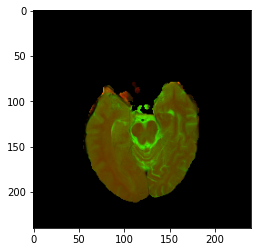

In [ ]:
plt.imshow(out)
plt.show()

In [ ]:
patient_name = str(list[0])
patient_name = re.findall('BRATS_*|\d+', patient_name)
print(patient_name[0]+patient_name[1])

BRATS_001


## done

In [ ]:
import cv2
import pathlib
import glob
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import nrrd
from PIL import Image

p_dir = pathlib.Path('/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/datasets/T1W2T2W/') #home directory

#Usage:
#get_img_list(path) => return path to img_list
img_T1 = get_img_list(p_dir / 'T1/')
img_T2 = get_img_list(p_dir / 'T2/')
img_CE = get_img_list(p_dir / 'trainB/')

OSError: ignored

In [ ]:
Imge_list_to_RGB(img_T1[0])

(<PIL.Image.Image image mode=L size=240x240 at 0x7F020895E450>,
 <PIL.Image.Image image mode=L size=240x240 at 0x7F020895EB90>,
 <PIL.Image.Image image mode=L size=240x240 at 0x7F020895E4D0>)

In [ ]:
path = p_dir / 'T1'
list = [i for i in path.glob('BRATS_*.nii.gz')]

OSError: ignored

In [ ]:
for i in range(len(img_T1)):
  # それぞれの画像のバンドを分割し、RGBAそれぞれのバンド画像を得る
  ar, _, _ = Imge_list_to_RGB(img_T1[i])
  _, bg, _ = Imge_list_to_RGB(img_T2[i])
  #_, _, fb = Imge_list_to_RGB(img_FLAIR[i])

  # 画像aのR(赤), G(緑)のバンドと、画像bのB（青）のバンドをマージする
  out = Image.merge('RGB', (ar, bg, pil_image))
  #output RGB-T1-T2-FLAIR
  path = p_dir / 'RGB-T1-T2--/'
  out.save(str(path)+'/'+patient_name[0]+patient_name[1]+ '_img_' + str(i) +'.png')

## base

In [ ]:
# それぞれの画像のバンドを分割し、RGBAそれぞれのバンド画像を得る
ar, _, _ = Imge_list_to_RGB(img_T1[60])
_, bg, _ = Imge_list_to_RGB(img_T2[60])
_, _, fb = Imge_list_to_RGB(img_FLAIR[60])

# 画像aのR(赤), G(緑)のバンドと、画像bのB（青）のバンドをマージする
out = Image.merge('RGB', (ar, bg, fb))
#output RGB-T1-T2-FLAIR
path = p_dir / 'RGB-T1-T2-FLAIR/'
out.save(str(path)+'/'+patient_name[0]+patient_name[1]+ '_img_' + str(60) +'.png')

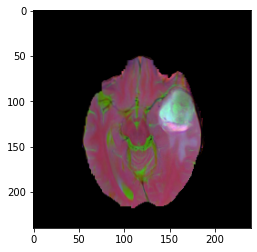

In [ ]:
#plt.imshow(out)
#plt.show()

## q

**集めたデータセットから学習を始めます**

---


!python train.py --dataroot ./datasets/xxxxxxx --name yyyyyyy_cyclegan --model cycle_gan

---
「xxxxxxx」の部分をデータセットのフォルダ名に、

「yyyyyyy」の部分をモデルに合わせて好きに変えます（データセットのフォルダ名と同じ方がなにかと分かりやすそうです）


例としてオーロラ変換の学習の場合はフォルダ名「yozora2aurora」なので、

「!python train.py --dataroot ./datasets/yozora2aurora --name yozora2aurora_cyclegan --model cycle_gan」となります

せっかく強いGPUなのでオプションで「--batch_size 4」まで付けてあげてもいいかもしれません

In [ ]:
!python train.py --dataroot ./datasets/T1W2T2W --name CE2RGB_T1_T2_FLIR_batch_1_cyclegan --model cycle_gan --batch_size 1

----------------- Options ---------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: ./datasets/T1W2T2W            	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
              display_env: main                          
             display_freq: 400                           
               display_id: 1                             
            display_ncols: 4                             
             display_port: 8097                          
           display_server: http://localhost              
          display_winsize: 256                           
                    epoch: latest                        
              



---
無事に学習が始まるとcheckpointsフォルダのimagesフォルダ


/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/checkpoints/yyyyyyy_cyclegan/web/images

の中に1epochごとに画像が生成されていきます！

**200epochを目指してぶん回しましょう！**


---



---



## ★中断した学習を再開する場合

現在は5epochごとに学習結果を保存する設定となっており、\
こちらはcheckpointsフォルダの中に「5_net_D_A.pth」のような形式で保存されています\
※上記Optionの「save_epoch_freq: 5」

---

中断した学習を再開したい場合は「--continue_train」をオプションに加えます\
デフォルトではepochカウントが1に初期化されてしまうので「--epoch_count 6」のように手動で変える必要があるようです（？）


---
例：10epochで中断したyozora2auroraの学習を続きから再開する場合

!python train.py --dataroot ./datasets/yozora2aurora --name yozora2aurora_cyclegan --model cycle_gan --continue_train --epoch_count 11

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix
!python train.py --dataroot ./datasets/T1W2T2W --name CE2RGB_T1_T2_FLIR_batch_1_cyclegan --model cycle_gan --batch_size 1 --continue_train --epoch_count 10

/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix
----------------- Options ---------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: True                          	[default: False]
                crop_size: 256                           
                 dataroot: ./datasets/T1W2T2W            	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
              display_env: main                          
             display_freq: 400                           
               display_id: 1                             
            display_ncols: 4                             
             display_port: 8097                          
           display_server: http://localhost              
          display_winsize: 

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix
!python test.py --dataroot ./datasets/T1W2T2W --name T1W2T2W_batch_1_cyclegan --model cycle_gan --epoch 50 --direction BtoA

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/checkpoints/T1W2T2W_cyclegan
!ls
import torch
a = torch.load("130_net_G_A.pth")
b = list(a.items())
b[0]

/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/checkpoints/T1W2T2W_cyclegan
100_net_D_A.pth  135_net_D_A.pth  35_net_D_A.pth  70_net_D_A.pth
100_net_D_B.pth  135_net_D_B.pth  35_net_D_B.pth  70_net_D_B.pth
100_net_G_A.pth  135_net_G_A.pth  35_net_G_A.pth  70_net_G_A.pth
100_net_G_B.pth  135_net_G_B.pth  35_net_G_B.pth  70_net_G_B.pth
105_net_D_A.pth  140_net_D_A.pth  40_net_D_A.pth  75_net_D_A.pth
105_net_D_B.pth  140_net_D_B.pth  40_net_D_B.pth  75_net_D_B.pth
105_net_G_A.pth  140_net_G_A.pth  40_net_G_A.pth  75_net_G_A.pth
105_net_G_B.pth  140_net_G_B.pth  40_net_G_B.pth  75_net_G_B.pth
10_net_D_A.pth	 145_net_D_A.pth  45_net_D_A.pth  80_net_D_A.pth
10_net_D_B.pth	 145_net_D_B.pth  45_net_D_B.pth  80_net_D_B.pth
10_net_G_A.pth	 145_net_G_A.pth  45_net_G_A.pth  80_net_G_A.pth
10_net_G_B.pth	 145_net_G_B.pth  45_net_G_B.pth  80_net_G_B.pth
110_net_D_A.pth  150_net_D_A.pth  50_net_D_A.pth  85_net_D_A.pth
110_net_D_B.pth  150_net_D_B.pth  50_net_D_B

[('model.1.weight',
  tensor([[[[-7.6758e-02, -1.0769e-02, -2.1098e-02,  ..., -3.4800e-02,
              6.8007e-03, -7.1469e-02],
            [-5.8041e-02, -4.1820e-03, -1.7985e-01,  ..., -1.4016e-01,
              7.1656e-02,  3.3530e-02],
            [ 3.9088e-02, -7.9767e-02, -1.5871e-01,  ...,  4.7932e-02,
             -4.0815e-03,  7.8517e-03],
            ...,
            [-6.7810e-02, -5.6807e-02,  4.3362e-02,  ...,  1.9394e-02,
              1.1796e-01, -7.8567e-02],
            [-2.3201e-02,  3.4712e-03,  2.4985e-02,  ...,  2.8645e-02,
             -3.5067e-02, -7.7531e-02],
            [ 4.7111e-04,  3.0237e-02, -9.3742e-02,  ..., -4.9964e-02,
             -4.0878e-02,  4.8826e-02]],
  
           [[-7.8687e-02, -2.3479e-02, -1.3368e-02,  ..., -2.9005e-02,
              7.0724e-03, -8.6151e-02],
            [-3.0746e-02, -2.4701e-02, -1.7856e-01,  ..., -1.4290e-01,
              3.6177e-02,  2.7009e-02],
            [ 3.5535e-02, -9.3739e-02, -1.2760e-01,  ...,  1.9020e-02,


# 参考文献

GitHub - junyanz/pytorch-CycleGAN-and-pix2pix: Image-to-Image Translation in PyTorch

https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix


@inproceedings{CycleGAN2017,
  title={Unpaired Image-to-Image Translation using Cycle-Consistent Adversarial Networkss},
  author={Zhu, Jun-Yan and Park, Taesung and Isola, Phillip and Efros, Alexei A},
  booktitle={Computer Vision (ICCV), 2017 IEEE International Conference on},
  year={2017}
}


@inproceedings{isola2017image,
  title={Image-to-Image Translation with Conditional Adversarial Networks},
  author={Isola, Phillip and Zhu, Jun-Yan and Zhou, Tinghui and Efros, Alexei A},
  booktitle={Computer Vision and Pattern Recognition (CVPR), 2017 IEEE Conference on},
  year={2017}
}

In [ ]:
import cv2
import pathlib
import glob
import re
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

p_dir = pathlib.Path('/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/') #home directory
path = p_dir / 'datasets/T1W2T2W/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations'
from natsort import natsorted

Case_list = []
files = [i for i in path.glob('*[!csv][!log]')]
for file in natsorted(files):
  Case_list.append(file)
  print(file.name)

TCGA-02-0006
TCGA-02-0009
TCGA-02-0011
TCGA-02-0027
TCGA-02-0033
TCGA-02-0034
TCGA-02-0037
TCGA-02-0046
TCGA-02-0047
TCGA-02-0054
TCGA-02-0059
TCGA-02-0064
TCGA-02-0068
TCGA-02-0069
TCGA-02-0070
TCGA-02-0075
TCGA-02-0085
TCGA-02-0086
TCGA-02-0087
TCGA-02-0102
TCGA-02-0106
TCGA-02-0116
TCGA-06-0119
TCGA-06-0122
TCGA-06-0130
TCGA-06-0137
TCGA-06-0138
TCGA-06-0139
TCGA-06-0142
TCGA-06-0145
TCGA-06-0149
TCGA-06-0154
TCGA-06-0158
TCGA-06-0162
TCGA-06-0164
TCGA-06-0176
TCGA-06-0177
TCGA-06-0179
TCGA-06-0182
TCGA-06-0184
TCGA-06-0185
TCGA-06-0187
TCGA-06-0188
TCGA-06-0190
TCGA-06-0192
TCGA-06-0238
TCGA-06-0240
TCGA-06-0644
TCGA-06-0646
TCGA-06-1084
TCGA-06-1802
TCGA-06-2570
TCGA-06-5408
TCGA-06-5413
TCGA-06-5417
TCGA-06-6389
TCGA-08-0355
TCGA-08-0356
TCGA-08-0359
TCGA-08-0360
TCGA-08-0385
TCGA-08-0389
TCGA-08-0390
TCGA-08-0392
TCGA-08-0509
TCGA-08-0512
TCGA-08-0520
TCGA-08-0522
TCGA-12-0616
TCGA-12-0776
TCGA-12-0829
TCGA-12-1094
TCGA-12-1098
TCGA-12-1598
TCGA-12-1601
TCGA-12-3650
TCGA-14-1456

In [ ]:
#fake T1 epoch 200
import cv2
import pathlib
import glob
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import nrrd
from PIL import Image

#real T1
p_dir = pathlib.Path('/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/') #home directory
path = p_dir / 'results' / Case_list[0].stem / 'T1W2T2W_batch_1_cyclegan/test_200/images'
img_list = []
images = []
img_resize = []
image = []

for i in range(0,155):
  s = '*_'+str(i+1)+'_real_B.png'
  img_list.append([j for j in path.glob(s)])

In [ ]:
path

PosixPath('/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/datasets/T1W2T2W/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0006/T1W2T2W_batch_1_cyclegan/test_200/images')

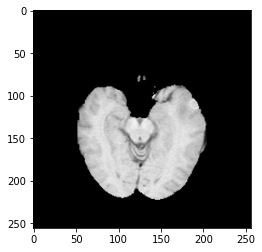

In [ ]:
T1_img = cv2.imread(str(img_list[50][0]), cv2.COLOR_BGR2RGB)
plt.imshow(T1_img)
plt.show()

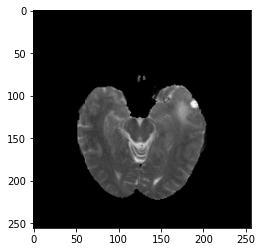

In [ ]:
T2_img = cv2.imread(str(img_list[50][0]), cv2.COLOR_BGR2RGB)
plt.imshow(T2_img)
plt.show()

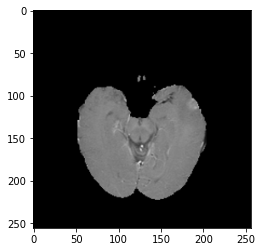

In [ ]:
CE_img = cv2.imread(str(img_list[50][0]), cv2.COLOR_BGR2RGB)
plt.imshow(CE_img)
plt.show()

In [ ]:
def Imge_list_to_RGB(img):
  img = Image.fromarray(img)
  r, g, b= img.split()
  return r, g, b

In [ ]:
ar, _, _ = Imge_list_to_RGB(CE_img)
_, bg, _ = Imge_list_to_RGB(T1_img)
#_, _, fb = Imge_list_to_RGB(img_FLAIR[i])
out = Image.merge('RGB', (ar, bg, pil_image))

ValueError: ignored

In [ ]:
plt.imshow(out)
plt.show()